# Analisis CHT-LCC Glasswool — Panci Listrik Mini Q2-8012

**Penelitian Hibah Internal LPPM UMB 2026** — Bakti Alpihuda

Notebook ini menjalankan analisis **per bagian**, supaya tiap langkah bisa
dibaca dan dijelaskan (misalnya saat monev). Angka yang keluar identik dengan
`lcc_optimizer.py` karena notebook ini **memanggil fungsi dari file tersebut**,
bukan menulis ulang rumusnya.

## Cara memakai
Jalankan sel satu per satu dari atas ke bawah dengan **Shift + Enter**.
Urutannya tidak boleh dilompati — sel bawah memakai hasil sel atas.

## Isi
| Bagian | Isi |
|---|---|
| 1 | Data hasil simulasi SolidWorks |
| 2 | Regresi Q(L) — kenapa model resistansi seri |
| 3 | Model biaya LCC (ISO 15686-5) |
| 4 | Optimasi — mencari ketebalan optimal L* |
| 5 | Mengapa ada batas: tutup jadi bottleneck |
| 6 | Sensitivitas — parameter mana yang paling berpengaruh |
| 7 | Monte Carlo — seberapa kokoh kesimpulannya |
| 8 | Ringkasan untuk laporan |

---
## 0. Persiapan

Memuat library dan fungsi dari `lcc_optimizer.py`.
Kalau sel ini error `ModuleNotFoundError`, jalankan dulu `3_Install_Kebutuhan.bat`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Semua fungsi & parameter diambil dari skrip utama — TIDAK ditulis ulang,
# supaya angka notebook tidak pernah berbeda dengan angka laporan.
import lcc_optimizer as lcc

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Library siap.")
print(f"Folder kerja : {os.getcwd()}")
print()
print("Parameter yang dipakai (dari lcc_optimizer.py):")
print(f"  Tarif listrik   : Rp {lcc.TARIF_KWH:,.2f} /kWh")
print(f"  Jam operasi     : {lcc.JAM_OPERASI} jam/hari  ({lcc.JAM_OPERASI*lcc.HARI_TAHUN:.0f} jam/tahun)")
print(f"  Diskonto        : {lcc.DISCOUNT_RATE*100:.2f} %")
print(f"  Inflasi tarif   : {lcc.INFLASI_TARIF*100:.1f} %")
print(f"  Umur analisis   : {lcc.UMUR_ANALISIS} tahun")
print(f"  Harga glasswool : Rp {lcc.HARGA_GW_PER_M2_MM:,} /m2/mm")
print(f"  Markup pasang   : {lcc.MARKUP_PASANG} x biaya material")

Library siap.
Folder kerja : G:\My Drive\Workspace Bakti\Dosen UMB - Teknik Mesin\penelitian\python

Parameter yang dipakai (dari lcc_optimizer.py):
  Tarif listrik   : Rp 1,444.70 /kWh
  Jam operasi     : 1.0 jam/hari  (365 jam/tahun)
  Diskonto        : 5.75 %
  Inflasi tarif   : 3.0 %
  Umur analisis   : 5 tahun
  Harga glasswool : Rp 4,500 /m2/mm
  Markup pasang   : 1.2 x biaya material


---
## 1. Data hasil simulasi CHT

Data berasal dari **SolidWorks Flow Simulation** (8 Agustus 2026), lima
konfigurasi K0–K4 dengan ketebalan glasswool 0–20 mm.

**Penting:** kalau di kolom catatan muncul `DEMO`, berarti data aslinya belum
terisi dan angkanya cuma estimasi — jangan dipakai untuk laporan.

In [2]:
df = lcc.baca_data_cht(lcc.DATA_FILE)

mode_demo = getattr(df, "_demo_mode", False)
if mode_demo:
    print("!!! PERINGATAN: MODE DEMO — angka di bawah BUKAN data nyata. !!!")
else:
    print("Status data: NYATA (terverifikasi, bukan mode demo).\n")

display(df)

Status data: NYATA (terverifikasi, bukan mode demo).



,Konfigurasi,L_mm,Q_Watt,Catatan
0,K0_NoInsulation,0,23.192,terverifikasi - SolidWorks Flow Sim 8 Agu 2026
1,K1_GW5mm,5,9.439,terverifikasi - SolidWorks Flow Sim 8 Agu 2026
2,K2_GW10mm,10,7.654,terverifikasi - SolidWorks Flow Sim 8 Agu 2026
3,K3_GW15mm,15,6.830,terverifikasi - SolidWorks Flow Sim 8 Agu 2026
4,K4_GW20mm,20,6.808,terverifikasi - SolidWorks Flow Sim 8 Agu 2026


### Membaca datanya

Perhatikan pola penurunannya — ini kunci seluruh penelitian:

In [3]:
Q0 = df["Q_Watt"].iloc[0]
for i in range(1, len(df)):
    L_now = df["L_mm"].iloc[i]
    Q_now = df["Q_Watt"].iloc[i]
    Q_prev = df["Q_Watt"].iloc[i - 1]
    turun_dari_K0 = (Q0 - Q_now) / Q0 * 100
    turun_dari_sebelumnya = Q_prev - Q_now
    print(f"L = {L_now:2.0f} mm : Q = {Q_now:6.3f} W  |  "
          f"turun {turun_dari_K0:5.1f}% dari K0  |  "
          f"tambahan hemat dari langkah sebelumnya: {turun_dari_sebelumnya:.3f} W")

print()
print("Amati: 5 mm pertama menghemat 13,753 W — sangat besar.")
print("Tetapi 5 mm terakhir (15->20 mm) hanya menghemat 0,022 W.")
print("Inilah 'diminishing returns' — dasar kenapa perlu dicari titik optimum.")

L =  5 mm : Q =  9.439 W  |  turun  59.3% dari K0  |  tambahan hemat dari langkah sebelumnya: 13.753 W
L = 10 mm : Q =  7.654 W  |  turun  67.0% dari K0  |  tambahan hemat dari langkah sebelumnya: 1.785 W
L = 15 mm : Q =  6.830 W  |  turun  70.6% dari K0  |  tambahan hemat dari langkah sebelumnya: 0.824 W
L = 20 mm : Q =  6.808 W  |  turun  70.6% dari K0  |  tambahan hemat dari langkah sebelumnya: 0.022 W

Amati: 5 mm pertama menghemat 13,753 W — sangat besar.
Tetapi 5 mm terakhir (15->20 mm) hanya menghemat 0,022 W.
Inilah 'diminishing returns' — dasar kenapa perlu dicari titik optimum.


---
## 2. Regresi Q(L) — memilih model yang benar

Data hanya 5 titik, tetapi kita perlu memperkirakan Q di ketebalan **mana pun**
(misal 11,3 mm) untuk optimasi. Jadi data perlu dicocokkan ke sebuah kurva.

Model yang dipakai — **resistansi seri**:

$$Q(L) = Q_\infty + \frac{A}{B + L}$$

- $Q_\infty$ = batas bawah rugi panas yang **tidak bisa dihilangkan** berapa pun
  tebal glasswool dinding. Secara fisis ini rugi panas lewat **tutup** yang
  tidak diinsulasi.
- $A/(B+L)$ = bagian dinding, yang menurun seiring tebal insulasi.

Bentuk ini sesuai fisika resistansi termal seri (konduksi + konveksi).

In [4]:
koef, fungsi_Q, R2 = lcc.regresi_cht(df)
Q_inf, A, B = koef

print("Hasil regresi:")
print(f"  Q_inf = {Q_inf:7.4f} W   <- batas bawah (rugi lewat tutup)")
print(f"  A     = {A:7.4f}")
print(f"  B     = {B:7.4f}")
print()
print(f"  R^2   = {R2:.5f}")
print()
if R2 >= 0.99:
    print("  R^2 di atas 0,99 -> kurva sangat cocok dengan data.")
else:
    print("  PERINGATAN: R^2 di bawah 0,99 — periksa kualitas data simulasi.")

Hasil regresi:
  Q_inf =  5.4636 W   <- batas bawah (rugi lewat tutup)
  A     = 25.3140
  B     =  1.4278

  R^2   = 0.99970

  R^2 di atas 0,99 -> kurva sangat cocok dengan data.


### Kenapa bukan polinomial?

Ini pertanyaan yang mungkin muncul saat monev, jadi mari dibuktikan langsung.
Kita bandingkan model resistansi seri dengan polinomial derajat 2 —
lalu lihat apa yang terjadi kalau kurvanya diteruskan sampai 40 mm.

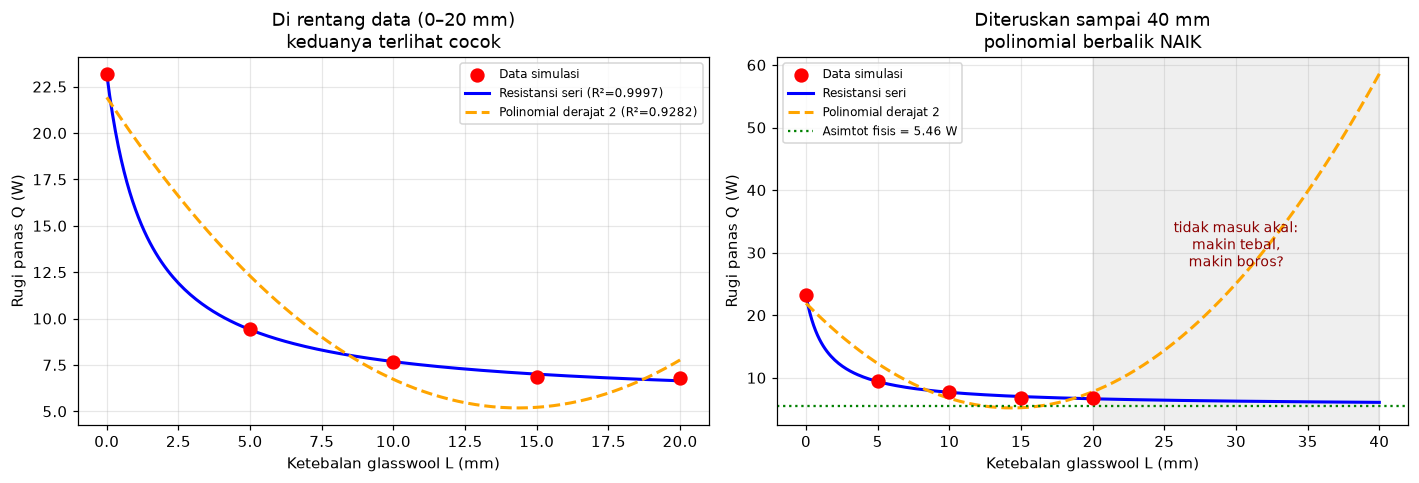

Pada L = 40 mm:
  Resistansi seri :   6.07 W  (turun menuju asimtot — wajar)
  Polinomial d-2  :  58.59 W  (naik melebihi K0! — mustahil)

Kesimpulan: polinomial derajat 2 punya R^2 lebih rendah DAN melanggar fisika.
Menambah insulasi tidak mungkin membuat rugi panas bertambah.
Karena itu model resistansi seri yang dipakai.


In [5]:
L_data = df["L_mm"].values.astype(float)
Q_data = df["Q_Watt"].values.astype(float)

# Polinomial derajat 2 sebagai pembanding
poli2 = np.poly1d(np.polyfit(L_data, Q_data, 2))
R2_poli2 = 1 - (np.sum((Q_data - poli2(L_data))**2) /
                np.sum((Q_data - Q_data.mean())**2))

L_jauh = np.linspace(0, 40, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Kiri: rentang data (0-20 mm) — dua model tampak sama-sama baik
L_dekat = np.linspace(0, 20, 200)
ax1.scatter(L_data, Q_data, color="red", s=70, zorder=5, label="Data simulasi")
ax1.plot(L_dekat, fungsi_Q(L_dekat), "b-", lw=2,
         label=f"Resistansi seri (R²={R2:.4f})")
ax1.plot(L_dekat, poli2(L_dekat), "orange", ls="--", lw=2,
         label=f"Polinomial derajat 2 (R²={R2_poli2:.4f})")
ax1.set_xlabel("Ketebalan glasswool L (mm)")
ax1.set_ylabel("Rugi panas Q (W)")
ax1.set_title("Di rentang data (0–20 mm)\nkeduanya terlihat cocok")
ax1.legend(fontsize=8)

# Kanan: diteruskan sampai 40 mm — polinomial jadi tidak masuk akal
ax2.scatter(L_data, Q_data, color="red", s=70, zorder=5, label="Data simulasi")
ax2.plot(L_jauh, fungsi_Q(L_jauh), "b-", lw=2, label="Resistansi seri")
ax2.plot(L_jauh, poli2(L_jauh), "orange", ls="--", lw=2, label="Polinomial derajat 2")
ax2.axhline(Q_inf, color="green", ls=":", lw=1.5,
            label=f"Asimtot fisis = {Q_inf:.2f} W")
ax2.axvspan(20, 40, color="grey", alpha=0.12)
ax2.text(30, poli2(38)*0.55, "tidak masuk akal:\nmakin tebal,\nmakin boros?",
         ha="center", fontsize=9, color="darkred")
ax2.set_xlabel("Ketebalan glasswool L (mm)")
ax2.set_ylabel("Rugi panas Q (W)")
ax2.set_title("Diteruskan sampai 40 mm\npolinomial berbalik NAIK")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Pada L = 40 mm:")
print(f"  Resistansi seri : {float(fungsi_Q(40)):6.2f} W  (turun menuju asimtot — wajar)")
print(f"  Polinomial d-2  : {float(poli2(40)):6.2f} W  (naik melebihi K0! — mustahil)")
print()
print("Kesimpulan: polinomial derajat 2 punya R^2 lebih rendah DAN melanggar fisika.")
print("Menambah insulasi tidak mungkin membuat rugi panas bertambah.")
print("Karena itu model resistansi seri yang dipakai.")

---
## 3. Model biaya — Life Cycle Cost (ISO 15686-5)

LCC menjumlahkan **dua biaya yang saling berlawanan**:

$$LCC(L) = \underbrace{C_{invest}(L)}_{\text{naik bila tebal}} + \underbrace{NPV_{energi}(Q(L))}_{\text{turun bila tebal}}$$

Karena satu naik dan satu turun, jumlahnya punya **titik minimum** — itulah L\*.

### 3a. Biaya investasi glasswool

Makin tebal, makin mahal — material lebih banyak dan luas selimut membesar.

In [6]:
for L_uji in [0, 5, 10, 11.28, 15, 20]:
    luas = lcc.luas_selimut(L_uji)
    biaya = lcc.biaya_investasi(L_uji)
    print(f"L = {L_uji:5.2f} mm : luas selimut = {luas:.4f} m2  ->  "
          f"investasi = Rp {biaya:8,.0f}")

print()
print("Sudah termasuk markup pemasangan 1,2 x biaya material.")

L =  0.00 mm : luas selimut = 0.0000 m2  ->  investasi = Rp        0
L =  5.00 mm : luas selimut = 0.0471 m2  ->  investasi = Rp    1,272
L = 10.00 mm : luas selimut = 0.0531 m2  ->  investasi = Rp    2,867
L = 11.28 mm : luas selimut = 0.0547 m2  ->  investasi = Rp    3,330
L = 15.00 mm : luas selimut = 0.0594 m2  ->  investasi = Rp    4,809
L = 20.00 mm : luas selimut = 0.0660 m2  ->  investasi = Rp    7,125

Sudah termasuk markup pemasangan 1,2 x biaya material.


### 3b. Biaya energi selama 5 tahun (NPV)

Rugi panas dikonversi ke rupiah, lalu didiskonto ke nilai sekarang.
Rumusnya memperhitungkan tarif listrik yang naik 3% per tahun.

In [7]:
print("Contoh: berapa biaya rugi panas K0 (tanpa insulasi) selama 5 tahun?\n")

Q_K0 = df["Q_Watt"].iloc[0]
energi_setahun = Q_K0 * lcc.JAM_OPERASI * lcc.HARI_TAHUN / 1000
biaya_setahun = lcc.biaya_energi_tahunan(Q_K0)
npv_5thn = lcc.npv_energi(Q_K0)

print(f"  Rugi panas         : {Q_K0:.3f} W")
print(f"  Energi terbuang    : {energi_setahun:.2f} kWh/tahun")
print(f"  Biaya tahun ke-1   : Rp {biaya_setahun:,.0f}")
print(f"  NPV 5 tahun        : Rp {npv_5thn:,.0f}")
print()
print("NPV lebih besar dari 5x biaya tahunan? Tidak — justru lebih kecil,")
print("karena uang di masa depan dinilai lebih rendah (didiskonto 5,75%/tahun).")

Contoh: berapa biaya rugi panas K0 (tanpa insulasi) selama 5 tahun?

  Rugi panas         : 23.192 W
  Energi terbuang    : 8.47 kWh/tahun
  Biaya tahun ke-1   : Rp 12,230
  NPV 5 tahun        : Rp 54,893

NPV lebih besar dari 5x biaya tahunan? Tidak — justru lebih kecil,
karena uang di masa depan dinilai lebih rendah (didiskonto 5,75%/tahun).


---
## 4. Optimasi — mencari ketebalan optimal L\*

Sekarang gabungkan keduanya dan cari titik terendah kurva LCC.

Dipakai **dua metode berbeda** yang harus memberi jawaban sama — ini
cross-check supaya hasilnya tidak salah.

In [8]:
L_opt, LCC_opt, L_bq = lcc.optimasi_lcc(fungsi_Q)

print("HASIL OPTIMASI")
print("=" * 46)
print(f"  L* metode 1 (minimize_scalar) : {L_opt:.2f} mm")
print(f"  L* metode 2 (brentq)          : {L_bq:.2f} mm")
print()
if abs(L_opt - L_bq) < 0.05:
    print("  OK — kedua metode sepakat. Hasil dapat dipercaya.")
else:
    print("  PERIKSA — kedua metode berbeda, optimasi bermasalah.")

LCC_K0 = lcc.lcc_total(0.0, fungsi_Q)
hemat = LCC_K0 - LCC_opt

print()
print(f"  LCC pada L*        : Rp {LCC_opt:,.0f}")
print(f"  LCC tanpa insulasi : Rp {LCC_K0:,.0f}")
print(f"  Penghematan        : Rp {hemat:,.0f}  ({hemat/LCC_K0*100:.1f}%)")

HASIL OPTIMASI
  L* metode 1 (minimize_scalar) : 11.28 mm
  L* metode 2 (brentq)          : 11.28 mm

  OK — kedua metode sepakat. Hasil dapat dipercaya.

  LCC pada L*        : Rp 20,977
  LCC tanpa insulasi : Rp 54,895
  Penghematan        : Rp 33,918  (61.8%)


### Grafik kurva LCC

Terlihat jelas dua garis putus-putus yang berlawanan arah, dan lembah minimum
di tengahnya.

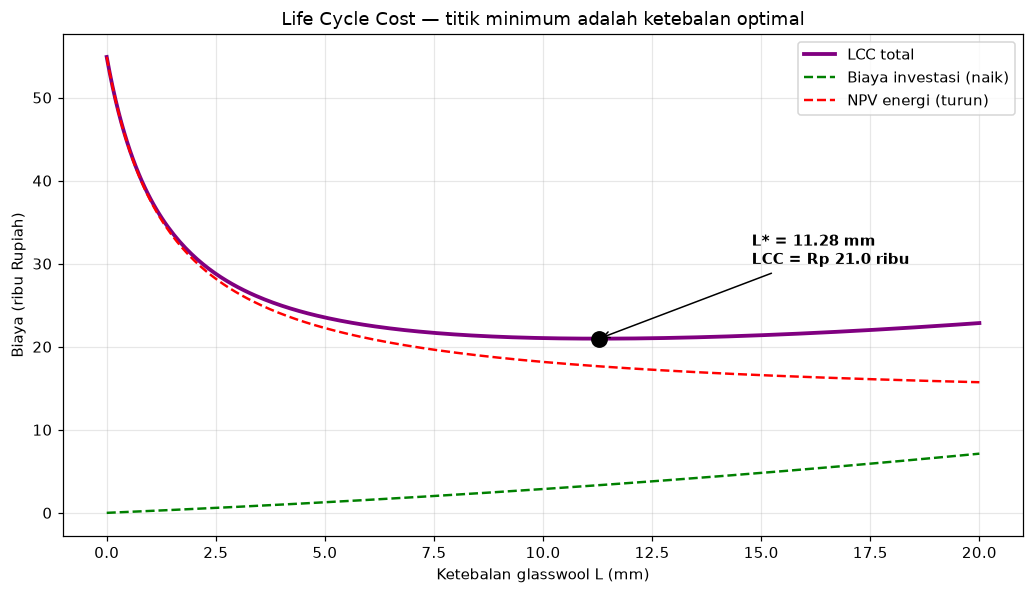

In [9]:
L_grid = np.linspace(0, 20, 300)
kurva_lcc = np.array([lcc.lcc_total(l, fungsi_Q) for l in L_grid])
kurva_inv = np.array([lcc.biaya_investasi(l) for l in L_grid])
kurva_npv = np.array([lcc.npv_energi(max(float(fungsi_Q(l)), 0.1)) for l in L_grid])

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(L_grid, kurva_lcc / 1000, color="purple", lw=2.5, label="LCC total")
ax.plot(L_grid, kurva_inv / 1000, "g--", lw=1.6, label="Biaya investasi (naik)")
ax.plot(L_grid, kurva_npv / 1000, "r--", lw=1.6, label="NPV energi (turun)")

ax.plot(L_opt, LCC_opt / 1000, "o", color="black", ms=10, zorder=6)
ax.annotate(f"L* = {L_opt:.2f} mm\nLCC = Rp {LCC_opt/1000:.1f} ribu",
            xy=(L_opt, LCC_opt / 1000),
            xytext=(L_opt + 3.5, LCC_opt / 1000 + 9),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, fontweight="bold")

ax.set_xlabel("Ketebalan glasswool L (mm)")
ax.set_ylabel("Biaya (ribu Rupiah)")
ax.set_title("Life Cycle Cost — titik minimum adalah ketebalan optimal")
ax.legend()
plt.tight_layout()
plt.show()

### Rekomendasi praktis

L\* = 11,28 mm bukan ukuran yang dijual di pasaran. Mari cek berapa kerugian
bila memakai tebal komersial terdekat.

In [10]:
print("Perbandingan dengan ketebalan yang dijual di pasaran:\n")
for L_pasar in [5, 10, 15, 20]:
    biaya = lcc.lcc_total(float(L_pasar), fungsi_Q)
    selisih = biaya - LCC_opt
    print(f"  {L_pasar:2d} mm : LCC = Rp {biaya:8,.0f}   "
          f"(+Rp {selisih:6,.0f} dari optimum, +{selisih/LCC_opt*100:4.1f}%)")

print()
print("Glasswool 10 mm hanya lebih mahal sedikit dari optimum teoretis,")
print("sementara 15 mm dan 20 mm justru menambah biaya tanpa manfaat berarti.")
print("=> Rekomendasi lapangan: glasswool 10 mm (konfigurasi K2).")

Perbandingan dengan ketebalan yang dijual di pasaran:

   5 mm : LCC = Rp   23,525   (+Rp  2,549 dari optimum, +12.1%)
  10 mm : LCC = Rp   21,042   (+Rp     65 dari optimum, + 0.3%)
  15 mm : LCC = Rp   21,388   (+Rp    412 dari optimum, + 2.0%)
  20 mm : LCC = Rp   22,853   (+Rp  1,876 dari optimum, + 8.9%)

Glasswool 10 mm hanya lebih mahal sedikit dari optimum teoretis,
sementara 15 mm dan 20 mm justru menambah biaya tanpa manfaat berarti.
=> Rekomendasi lapangan: glasswool 10 mm (konfigurasi K2).


---
## 5. Mengapa ada batas? Tutup jadi penghambat

Ini **temuan utama** penelitian. Rugi panas tidak bisa ditekan terus-menerus
karena tutup panci tidak diinsulasi.

Data di bawah dari hasil simulasi terverifikasi (8 Agu 2026).

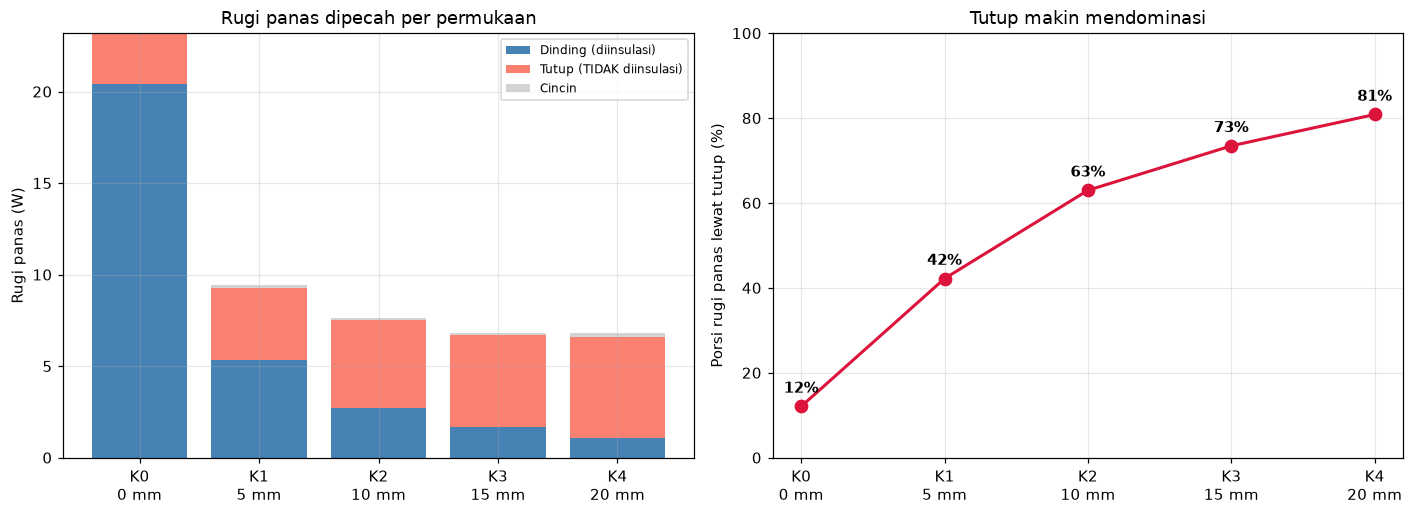

Pembacaan:
  K0 : tutup menyumbang 12% rugi panas — dinding yang dominan.
  K4 : tutup menyumbang 81% — dinding sudah hampir tidak berperan.

Dinding berhasil ditekan dari 20,39 W jadi 1,07 W (turun 95%),
tetapi rugi lewat tutup JUSTRU NAIK dari 2,80 W ke 5,50 W.

Sebabnya: panas yang tadinya lolos lewat dinding kini 'dialihkan' ke tutup.
Inilah asal asimtot Q_inf pada regresi — menebalkan dinding saja
tidak akan menolong lagi setelah titik tertentu.

IMPLIKASI RISET LANJUTAN: insulasi tutup berpotensi lebih besar
daripada menambah tebal dinding.


In [11]:
Q_dinding = np.array([20.390, 5.308, 2.695, 1.672, 1.072])
Q_tutup   = np.array([2.801, 3.983, 4.820, 5.017, 5.503])
Q_cincin  = np.array([0.000, 0.149, 0.138, 0.141, 0.232])
label_k   = ["K0\n0 mm", "K1\n5 mm", "K2\n10 mm", "K3\n15 mm", "K4\n20 mm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

x = np.arange(5)
ax1.bar(x, Q_dinding, label="Dinding (diinsulasi)", color="steelblue")
ax1.bar(x, Q_tutup, bottom=Q_dinding, label="Tutup (TIDAK diinsulasi)", color="salmon")
ax1.bar(x, Q_cincin, bottom=Q_dinding + Q_tutup, label="Cincin", color="lightgrey")
ax1.set_xticks(x); ax1.set_xticklabels(label_k)
ax1.set_ylabel("Rugi panas (W)")
ax1.set_title("Rugi panas dipecah per permukaan")
ax1.legend(fontsize=8)

persen_tutup = Q_tutup / (Q_dinding + Q_tutup + Q_cincin) * 100
ax2.plot(x, persen_tutup, "o-", color="crimson", lw=2, ms=8)
for i, p in enumerate(persen_tutup):
    ax2.annotate(f"{p:.0f}%", (i, p), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(label_k)
ax2.set_ylabel("Porsi rugi panas lewat tutup (%)")
ax2.set_title("Tutup makin mendominasi")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Pembacaan:")
print(f"  K0 : tutup menyumbang {persen_tutup[0]:.0f}% rugi panas — dinding yang dominan.")
print(f"  K4 : tutup menyumbang {persen_tutup[4]:.0f}% — dinding sudah hampir tidak berperan.")
print()
print("Dinding berhasil ditekan dari 20,39 W jadi 1,07 W (turun 95%),")
print("tetapi rugi lewat tutup JUSTRU NAIK dari 2,80 W ke 5,50 W.")
print()
print("Sebabnya: panas yang tadinya lolos lewat dinding kini 'dialihkan' ke tutup.")
print("Inilah asal asimtot Q_inf pada regresi — menebalkan dinding saja")
print("tidak akan menolong lagi setelah titik tertentu.")
print()
print("IMPLIKASI RISET LANJUTAN: insulasi tutup berpotensi lebih besar")
print("daripada menambah tebal dinding.")

---
## 6. Sensitivitas — parameter mana yang paling menentukan?

Tiap parameter diubah naik-turun satu per satu (metode One-At-a-Time),
lalu dilihat seberapa besar LCC berubah.

Sel ini memerlukan waktu sekitar 10–20 detik.

In [12]:
df_sens = lcc.analisis_sensitivitas(fungsi_Q)
display(df_sens)

,Parameter,Arah,Nilai Baru,L* (mm),dLCC (%),dL* (mm)
0,Tarif Listrik,Naik,1733.6400,12.24,16.66,0.96
1,Tarif Listrik,Turun,1155.7600,10.18,-17.02,-1.10
2,Discount Rate,Naik,0.0775,11.00,-4.50,-0.28
3,Discount Rate,Turun,0.0375,11.57,4.89,0.29
4,Inflasi Tarif,Naik,0.0450,11.43,2.42,0.15
5,Inflasi Tarif,Turun,0.0150,11.14,-2.36,-0.14
6,Harga Glasswool,Naik,5400.0000,10.38,3.01,-0.90
7,Harga Glasswool,Turun,3600.0000,12.47,-3.38,1.19
8,Jam Operasi,Naik,1.5000,13.51,41.14,2.22
9,Jam Operasi,Turun,0.5000,8.14,-43.60,-3.14


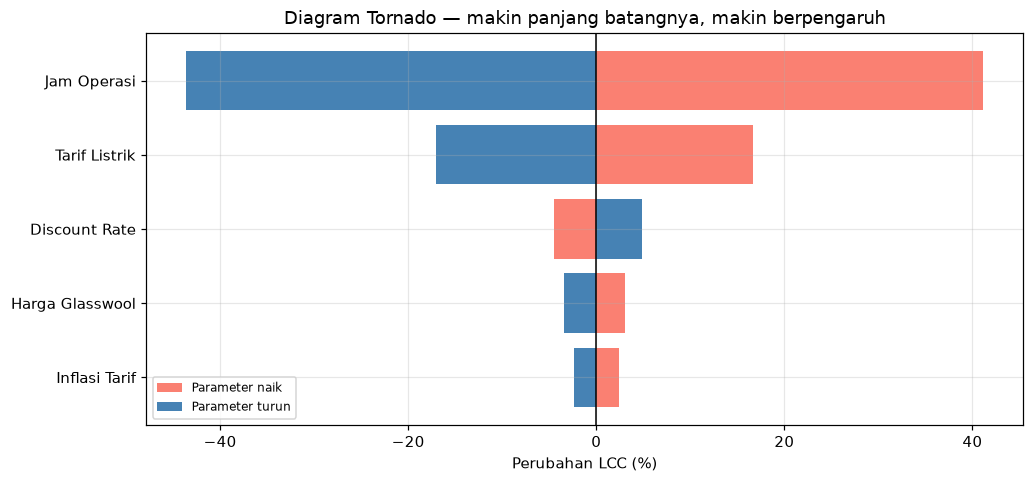

Urutan pengaruh (terbesar di atas):
  Jam Operasi        :  84.7 % rentang total
  Tarif Listrik      :  33.7 % rentang total
  Discount Rate      :   9.4 % rentang total
  Harga Glasswool    :   6.4 % rentang total
  Inflasi Tarif      :   4.8 % rentang total

JAM OPERASI paling berpengaruh. Artinya, asumsi 1 jam/hari adalah
angka paling kritis dalam penelitian ini dan perlu dipertahankan
dasarnya saat monev (proposal bagian 2.5.2).

Sebaliknya, harga glasswool dan suku bunga hampir tidak menggeser L*,
jadi kesimpulan tetap berlaku meski harga pasar berubah.


In [13]:
params = list(lcc.SENSITIVITY_PARAMS.keys())
naik = df_sens[df_sens["Arah"] == "Naik"].set_index("Parameter")["dLCC (%)"]
turun = df_sens[df_sens["Arah"] == "Turun"].set_index("Parameter")["dLCC (%)"]

urut = sorted(params, key=lambda p: abs(naik[p]) + abs(turun[p]))
y = np.arange(len(urut))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.barh(y, [naik[p] for p in urut], color="salmon", label="Parameter naik")
ax.barh(y, [turun[p] for p in urut], color="steelblue", label="Parameter turun")
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y); ax.set_yticklabels(urut)
ax.set_xlabel("Perubahan LCC (%)")
ax.set_title("Diagram Tornado — makin panjang batangnya, makin berpengaruh")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Urutan pengaruh (terbesar di atas):")
for p in reversed(urut):
    print(f"  {p:18s} : {abs(naik[p]) + abs(turun[p]):5.1f} % rentang total")

print()
print("JAM OPERASI paling berpengaruh. Artinya, asumsi 1 jam/hari adalah")
print("angka paling kritis dalam penelitian ini dan perlu dipertahankan")
print("dasarnya saat monev (proposal bagian 2.5.2).")
print()
print("Sebaliknya, harga glasswool dan suku bunga hampir tidak menggeser L*,")
print("jadi kesimpulan tetap berlaku meski harga pasar berubah.")

---
## 7. Monte Carlo — seberapa kokoh kesimpulannya?

Sensitivitas menguji satu parameter pada satu waktu. Kenyataannya semua
parameter bisa meleset **bersamaan**. Monte Carlo menguji 10.000 kombinasi acak.

**Sel ini paling lama — sekitar 1–2 menit.** Tunggu sampai selesai.

In [14]:
mc = lcc.monte_carlo(fungsi_Q)

print("HASIL MONTE CARLO (10.000 skenario)")
print("=" * 46)
print(f"  L* rata-rata     : {mc['L_mean']:.2f} mm")
print(f"  Simpangan baku   : {mc['L_std']:.2f} mm")
print(f"  Rentang P5–P95   : {mc['L_p5']:.2f} – {mc['L_p95']:.2f} mm")
print(f"  LCC rata-rata    : Rp {mc['LCC_mean']:,.0f}")

HASIL MONTE CARLO (10.000 skenario)
  L* rata-rata     : 11.18 mm
  Simpangan baku   : 1.49 mm
  Rentang P5–P95   : 8.65 – 13.57 mm
  LCC rata-rata    : Rp 20,841


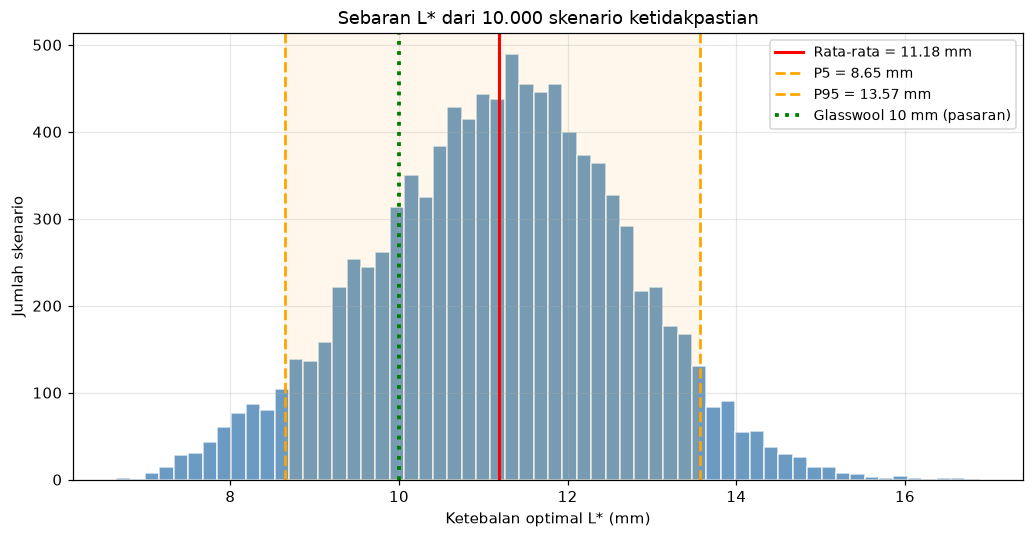

Sebanyak 95.6% skenario menghasilkan L* antara 8–14 mm.

Garis hijau (10 mm) berada di dalam rentang P5–P95, artinya glasswool
10 mm tetap pilihan wajar meski asumsi ekonomi meleset cukup jauh.
=> Kesimpulan penelitian ini KOKOH terhadap ketidakpastian.


In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.hist(mc["L_opts"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(mc["L_mean"], color="red", lw=2, label=f"Rata-rata = {mc['L_mean']:.2f} mm")
ax.axvline(mc["L_p5"], color="orange", ls="--", lw=1.8, label=f"P5 = {mc['L_p5']:.2f} mm")
ax.axvline(mc["L_p95"], color="orange", ls="--", lw=1.8, label=f"P95 = {mc['L_p95']:.2f} mm")
ax.axvspan(mc["L_p5"], mc["L_p95"], color="orange", alpha=0.08)
ax.axvline(10, color="green", lw=2.5, ls=":", label="Glasswool 10 mm (pasaran)")
ax.set_xlabel("Ketebalan optimal L* (mm)")
ax.set_ylabel("Jumlah skenario")
ax.set_title("Sebaran L* dari 10.000 skenario ketidakpastian")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

dalam_rentang = ((mc["L_opts"] >= 8) & (mc["L_opts"] <= 14)).mean() * 100
print(f"Sebanyak {dalam_rentang:.1f}% skenario menghasilkan L* antara 8–14 mm.")
print()
print("Garis hijau (10 mm) berada di dalam rentang P5–P95, artinya glasswool")
print("10 mm tetap pilihan wajar meski asumsi ekonomi meleset cukup jauh.")
print("=> Kesimpulan penelitian ini KOKOH terhadap ketidakpastian.")

---
## 8. Ringkasan untuk laporan

Angka-angka siap salin ke dokumen.

In [16]:
print("=" * 62)
print("  RINGKASAN — CHT-LCC GLASSWOOL Q2-8012")
print("=" * 62)
print()
print("MODEL")
print(f"  Persamaan    : Q(L) = {Q_inf:.4f} + {A:.4f}/({B:.4f} + L)")
print(f"  Ketepatan    : R^2 = {R2:.5f}")
print()
print("HASIL OPTIMASI")
print(f"  L* teoretis  : {L_opt:.2f} mm")
print(f"  LCC minimum  : Rp {LCC_opt:,.0f}")
print(f"  LCC tanpa insulasi : Rp {LCC_K0:,.0f}")
print(f"  Penghematan  : Rp {hemat:,.0f} ({hemat/LCC_K0*100:.1f}%)")
print(f"  Rekomendasi  : glasswool 10 mm (K2) — tebal komersial terdekat")
print()
print("KETAHANAN HASIL")
print(f"  Monte Carlo  : L* = {mc['L_mean']:.2f} +/- {mc['L_std']:.2f} mm")
print(f"  Rentang P5-P95: {mc['L_p5']:.2f} - {mc['L_p95']:.2f} mm")
print(f"  Parameter paling berpengaruh : Jam operasi")
print()
print("TEMUAN UTAMA")
print(f"  Rugi panas lewat tutup naik dari {persen_tutup[0]:.0f}% (K0) ke {persen_tutup[4]:.0f}% (K4).")
print(f"  Tutup tanpa insulasi menjadi penghambat — membatasi manfaat")
print(f"  penambahan tebal glasswool dinding (asimtot {Q_inf:.2f} W).")
print()
print("=" * 62)

  RINGKASAN — CHT-LCC GLASSWOOL Q2-8012

MODEL
  Persamaan    : Q(L) = 5.4636 + 25.3140/(1.4278 + L)
  Ketepatan    : R^2 = 0.99970

HASIL OPTIMASI
  L* teoretis  : 11.28 mm
  LCC minimum  : Rp 20,977
  LCC tanpa insulasi : Rp 54,895
  Penghematan  : Rp 33,918 (61.8%)
  Rekomendasi  : glasswool 10 mm (K2) — tebal komersial terdekat

KETAHANAN HASIL
  Monte Carlo  : L* = 11.18 +/- 1.49 mm
  Rentang P5-P95: 8.65 - 13.57 mm
  Parameter paling berpengaruh : Jam operasi

TEMUAN UTAMA
  Rugi panas lewat tutup naik dari 12% (K0) ke 81% (K4).
  Tutup tanpa insulasi menjadi penghambat — membatasi manfaat
  penambahan tebal glasswool dinding (asimtot 5.46 W).



---
## Catatan penting

1. **Angka resmi laporan** sebaiknya diambil dari `lcc_optimizer.py`
   (lewat `1_Jalankan_Analisis_LCC.bat`). Notebook ini memakai fungsi yang
   sama persis, jadi hasilnya identik — tetapi satu sumber angka lebih aman.

2. **Diskonto 5,75%** di skrip berbeda dengan proposal yang menulis 4,5%.
   Skrip memakai BI-Rate resmi 22 Juli 2026. Perbedaan ini perlu dijelaskan
   di laporan agar tidak dianggap tidak konsisten. Dampaknya kecil (±5%),
   dan sudah diuji di bagian sensitivitas.

3. **Daya pemanas 330 W** masih berstatus perlu verifikasi fisik (dari label
   produk). Nilai ini tidak dipakai dalam perhitungan LCC, jadi tidak
   memengaruhi hasil di atas.

4. **Bila data simulasi diperbarui**, cukup ubah `data_CHT_hasil.csv` lalu
   jalankan ulang notebook dari atas — seluruh angka dan grafik ikut menyesuaikan.